# Brain Age Prediction: MS patients - baseline scans

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy import stats

In [2]:
# Define paths to the project directory and prediction files
# Separate CSV files are used for the unsmoothed and smoothed models
project_path = Path("/Users/anneaasengen/MS_project")

# Predictions from the unsmoothed model 
pred_csv = project_path / "Prediksjoner" / "MS_brain_age_predictions_baseline.csv"

# Predictions from the smoothed model 
smooth_pred_csv = project_path / "prediksjoner_smoothed" / "smoothed_MS_brain_age_predictions_baseline.csv"

# Info abour symtom duration and disease duration
dato_csv = project_path / "Metadata_OFAMS" / "dato.csv"

In [3]:
df_unsmooth = pd.read_csv(pred_csv) # predictions from the unsmoothed model
df_smooth = pd.read_csv(smooth_pred_csv) # predictions from the smoothed model
df_dato = pd.read_csv(dato_csv) # Info about symptom and disease duration

In [4]:
df_unsmooth.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,BAG_residual
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,1.5,33.492504,-1.507496,33.919716,-1.080284,mild,-12.139774
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,2.5,40.867573,16.867573,41.207672,17.207672,mild,-2.228348
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,104,F,48.0,1.5,40.905470,-7.094528,41.245125,-6.754875,mild,-7.914830
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1101,F,46.0,2.0,44.873960,-1.126041,45.166737,-0.833263,mild,-3.516223
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1102,F,39.0,1.5,48.496895,9.496895,48.746880,9.746880,mild,1.733400


In [5]:
df_smooth.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,BAG_residual
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,1.5,32.195694,-2.804306,32.905727,-2.094273,mild,-7.319295
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,2.5,36.474022,12.474022,37.120200,13.120201,mild,-1.392804
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,104,F,48.0,1.5,35.260303,-12.739697,35.924600,-12.075401,mild,-6.323716
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1101,F,46.0,2.0,36.009117,-9.990883,36.662235,-9.337765,mild,-5.274804
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1102,F,39.0,1.5,46.991196,7.991196,47.480396,8.480396,mild,6.632822


In [6]:
# Define variables: Unsmoothed model

# Common x-variable (chronological age)
x_unsmooth = df_unsmooth["age_BL"]

# Predicted age variables
y_pred_unsmooth_raw = df_unsmooth["predicted_age"]
y_pred_unsmooth_bc = df_unsmooth["predicted_age_bc"]

# BAG variables
y_bag_unsmooth_raw = df_unsmooth["brain_age_gap"]
y_bag_unsmooth_bc = df_unsmooth["brain_age_gap_bc"]

# Linear fits: predicted age
m_pred_unsmooth_raw, b_pred_unsmooth_raw = np.polyfit(x_unsmooth, y_pred_unsmooth_raw, 1)
m_pred_unsmooth_bc, b_pred_unsmooth_bc = np.polyfit(x_unsmooth, y_pred_unsmooth_bc, 1)

# Linear fits: BAG
m_bag_unsmooth_raw, b_bag_unsmooth_raw = np.polyfit(x_unsmooth, y_bag_unsmooth_raw, 1)
m_bag_unsmooth_bc, b_bag_unsmooth_bc = np.polyfit(x_unsmooth, y_bag_unsmooth_bc, 1)

In [7]:
# Define variables: Smoothed model

# Common x-variable (chronological age)
x_smooth = df_smooth["age_BL"]

# Predicted age variables
y_pred_smooth_raw = df_smooth["predicted_age"]
y_pred_smooth_bc = df_smooth["predicted_age_bc"]

# BAG variables
y_bag_smooth_raw = df_smooth["brain_age_gap"]
y_bag_smooth_bc = df_smooth["brain_age_gap_bc"]

# Linear fits: predicted age
m_pred_smooth_raw, b_pred_smooth_raw = np.polyfit(x_smooth, y_pred_smooth_raw, 1)
m_pred_smooth_bc, b_pred_smooth_bc = np.polyfit(x_smooth, y_pred_smooth_bc, 1)

# Linear fits: BAG
m_bag_smooth_raw, b_bag_smooth_raw = np.polyfit(x_smooth, y_bag_smooth_raw, 1)
m_bag_smooth_bc, b_bag_smooth_bc = np.polyfit(x_smooth, y_bag_smooth_bc, 1)

## Plot: Predicted vs cronological age

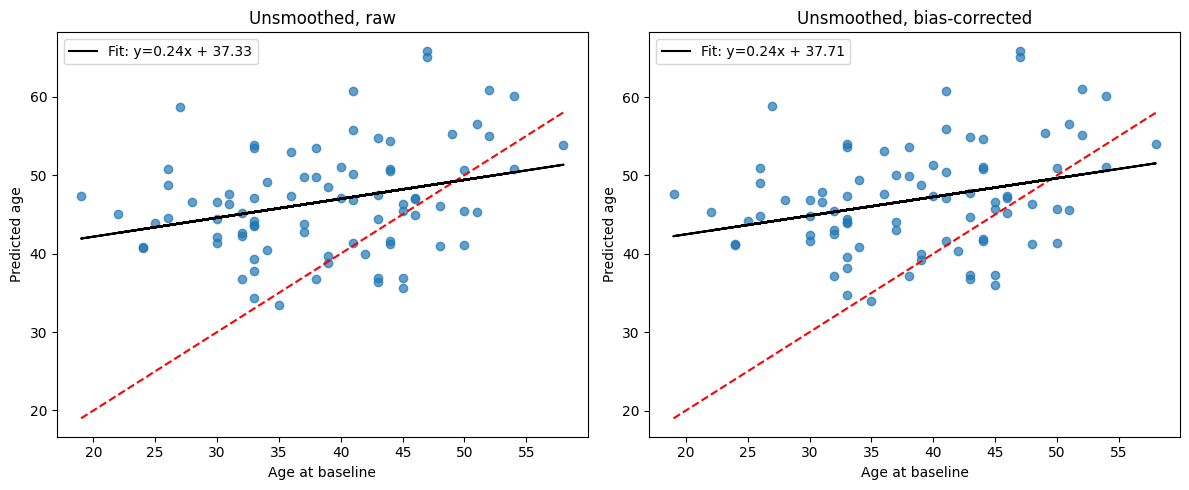

In [8]:
# Create side-by-side plots for the unsmoothed model
# Left: raw predictions
# Right: bias-corrected predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Unsmoothed raw

# Scatter plot showing chronological age vs predicted brain age
axes[0].scatter(x_unsmooth, y_pred_unsmooth_raw, alpha=0.7)

axes[0].plot([x_unsmooth.min(), x_unsmooth.max()],
             [x_unsmooth.min(), x_unsmooth.max()],
             linestyle="--", color="red")

# Add identity line representing perfect prediction
# Points above the line indicate overestimation
# Points below indicate underestimation
axes[0].plot(x_unsmooth,
             m_pred_unsmooth_raw * x_unsmooth + b_pred_unsmooth_raw,
             color="black",
             label=f"Fit: y={m_pred_unsmooth_raw:.2f}x + {b_pred_unsmooth_raw:.2f}")

# Formatting
axes[0].set_title("Unsmoothed, raw")
axes[0].set_xlabel("Age at baseline")
axes[0].set_ylabel("Predicted age")
axes[0].legend()


# Unsmoothed bias-corrected
axes[1].scatter(x_unsmooth, y_pred_unsmooth_bc, alpha=0.7)

# Identity line for reference
axes[1].plot([x_unsmooth.min(), x_unsmooth.max()],
             [x_unsmooth.min(), x_unsmooth.max()],
             linestyle="--", color="red")

axes[1].plot(x_unsmooth,
             m_pred_unsmooth_bc * x_unsmooth + b_pred_unsmooth_bc,
             color="black",
             label=f"Fit: y={m_pred_unsmooth_bc:.2f}x + {b_pred_unsmooth_bc:.2f}")

# Formatting
axes[1].set_title("Unsmoothed, bias-corrected")
axes[1].set_xlabel("Age at baseline")
axes[1].set_ylabel("Predicted age")
axes[1].legend()

# Improve spacing between subplots
plt.tight_layout()
#plt.savefig("MS_baseline_pred_vs_age.png", dpi=300, bbox_inches="tight")
plt.show()


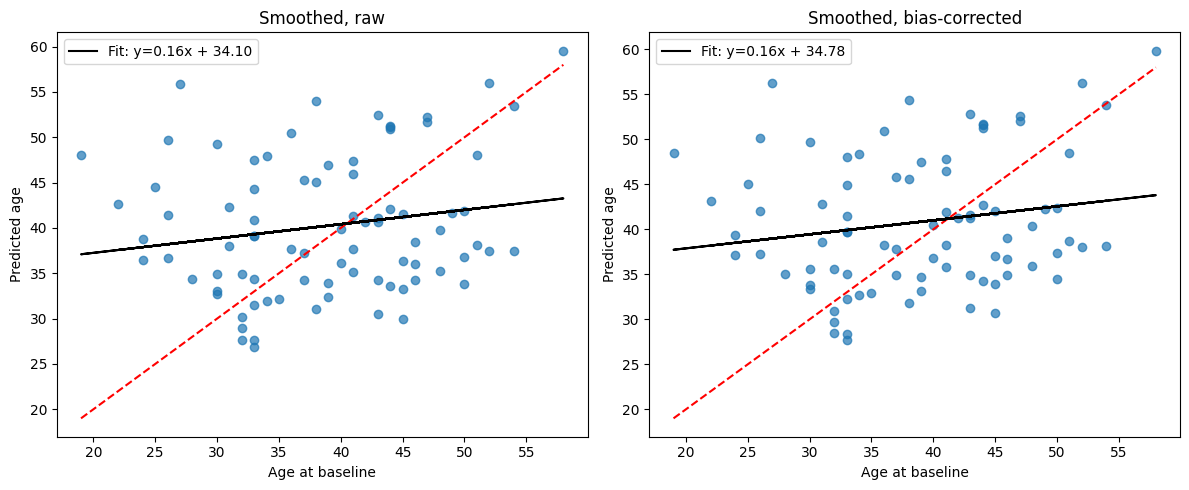

In [9]:
# Create equivalent plots for the smoothed model

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Smoothed raw
axes[0].scatter(x_smooth, y_pred_smooth_raw, alpha=0.7)

# Identity line showing perfect agreement
axes[0].plot([x_smooth.min(), x_smooth.max()],
             [x_smooth.min(), x_smooth.max()],
             linestyle="--", color="red")

axes[0].plot(x_smooth,
             m_pred_smooth_raw * x_smooth + b_pred_smooth_raw,
             color="black",
             label=f"Fit: y={m_pred_smooth_raw:.2f}x + {b_pred_smooth_raw:.2f}")

axes[0].set_title("Smoothed, raw")
axes[0].set_xlabel("Age at baseline")
axes[0].set_ylabel("Predicted age")
axes[0].legend()


# Smoothed bias-corrected
axes[1].scatter(x_smooth, y_pred_smooth_bc, alpha=0.7)

axes[1].plot([x_smooth.min(), x_smooth.max()],
             [x_smooth.min(), x_smooth.max()],
             linestyle="--", color="red")

axes[1].plot(x_smooth,
             m_pred_smooth_bc * x_smooth + b_pred_smooth_bc,
             color="black",
             label=f"Fit: y={m_pred_smooth_bc:.2f}x + {b_pred_smooth_bc:.2f}")

axes[1].set_title("Smoothed, bias-corrected")
axes[1].set_xlabel("Age at baseline")
axes[1].set_ylabel("Predicted age")
axes[1].legend()

plt.tight_layout()
#plt.savefig("smooth_MS_baseline_pred_vs_age.png", dpi=300, bbox_inches="tight")
plt.show()

Observation:

Both the unsmoothed and smoothed models show regression-to-the-mean effects, where younger subjects tend to be overestimated and older subjects tend to be underestimated.

The bias correction does not remove this pattern. In addition, the smoothed model appears to produce a larger proportion of negative BAG values compared with the unsmoothed model.

## Plot: BAG vs cronological age

Unsmoothed model:
Mean BAG (raw): 7.9712842458702
Mean BAG (bias-corrected): 8.242847442626953


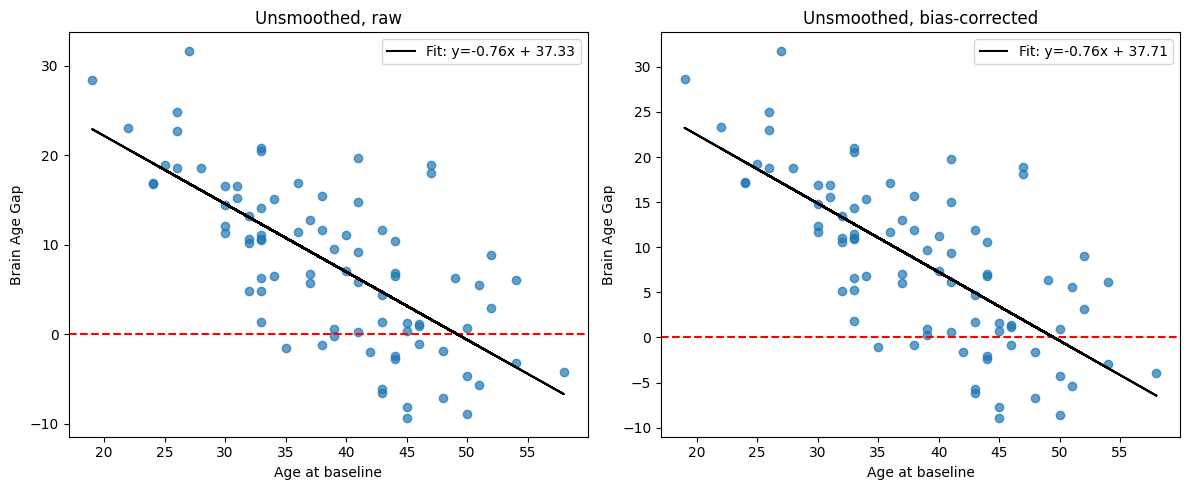

In [10]:
# Print average BAG values for the unsmoothed model
# Positive BAG indicates older-appearing brains,
# while negative BAG indicates younger-appearing brains
print("Unsmoothed model:")
print("Mean BAG (raw):", df_unsmooth["brain_age_gap"].mean())
print("Mean BAG (bias-corrected):", df_unsmooth["brain_age_gap_bc"].mean())

# Create plots showing BAG as a function of chronological age

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Unsmoothed raw

axes[0].scatter(x_unsmooth, y_bag_unsmooth_raw, alpha=0.7)

# Horizontal line at BAG = 0
# Values above zero indicate older predicted age than chronological age
axes[0].axhline(0, linestyle="--", color="red")

axes[0].plot(x_unsmooth,
             m_bag_unsmooth_raw * x_unsmooth + b_bag_unsmooth_raw,
             color="black",
             label=f"Fit: y={m_bag_unsmooth_raw:.2f}x + {b_bag_unsmooth_raw:.2f}")

axes[0].set_title("Unsmoothed, raw")
axes[0].set_xlabel("Age at baseline")
axes[0].set_ylabel("Brain Age Gap")
axes[0].legend()


# Unsmoothed bias-corrected
axes[1].scatter(x_unsmooth, y_bag_unsmooth_bc, alpha=0.7)

axes[1].axhline(0, linestyle="--", color="red")

axes[1].plot(x_unsmooth,
             m_bag_unsmooth_bc * x_unsmooth + b_bag_unsmooth_bc,
             color="black",
             label=f"Fit: y={m_bag_unsmooth_bc:.2f}x + {b_bag_unsmooth_bc:.2f}")

axes[1].set_title("Unsmoothed, bias-corrected")
axes[1].set_xlabel("Age at baseline")
axes[1].set_ylabel("Brain Age Gap")
axes[1].legend()

plt.tight_layout()
#plt.savefig("MS_baseline_BAG_vs_age.png", dpi=300, bbox_inches="tight")
plt.show()

Smoothed model:
Mean BAG (raw): 1.5114881446562618
Mean BAG (bias-corrected): 2.101899870906968


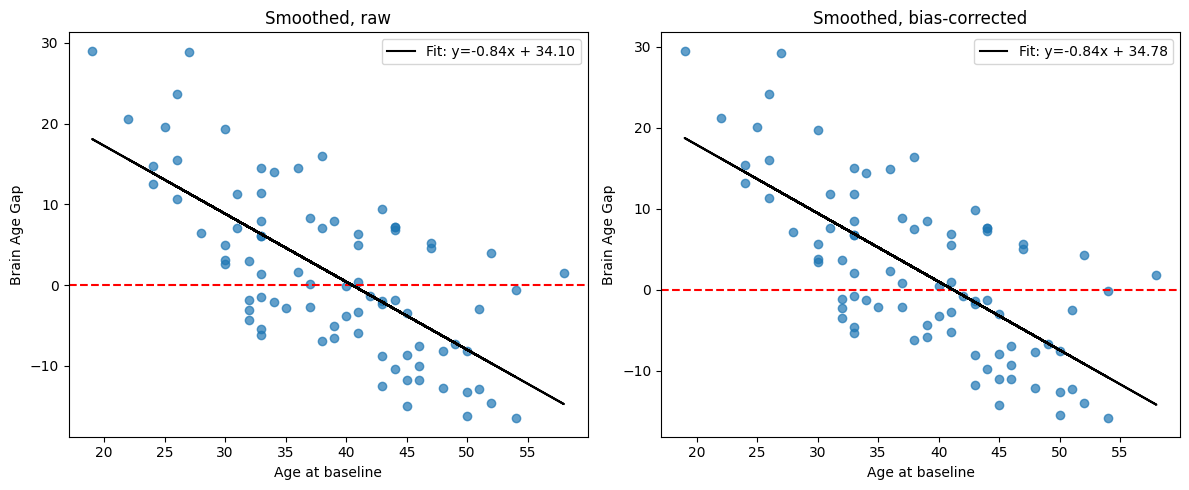

In [11]:
# Repeat the same BAG analysis for the smoothed model

print("Smoothed model:")
print("Mean BAG (raw):", df_smooth["brain_age_gap"].mean())
print("Mean BAG (bias-corrected):", df_smooth["brain_age_gap_bc"].mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Smoothed raw
axes[0].scatter(x_smooth, y_bag_smooth_raw, alpha=0.7)

axes[0].axhline(0, linestyle="--", color="red")

axes[0].plot(x_smooth,
             m_bag_smooth_raw * x_smooth + b_bag_smooth_raw,
             color="black",
             label=f"Fit: y={m_bag_smooth_raw:.2f}x + {b_bag_smooth_raw:.2f}")

axes[0].set_title("Smoothed, raw")
axes[0].set_xlabel("Age at baseline")
axes[0].set_ylabel("Brain Age Gap")
axes[0].legend()

# Smoothed bias-corrected
axes[1].scatter(x_smooth, y_bag_smooth_bc, alpha=0.7)

axes[1].axhline(0, linestyle="--", color="red")

axes[1].plot(x_smooth,
             m_bag_smooth_bc * x_smooth + b_bag_smooth_bc,
             color="black",
             label=f"Fit: y={m_bag_smooth_bc:.2f}x + {b_bag_smooth_bc:.2f}")

axes[1].set_title("Smoothed, bias-corrected")
axes[1].set_xlabel("Age at baseline")
axes[1].set_ylabel("Brain Age Gap")
axes[1].legend()

plt.tight_layout()
#plt.savefig("smooth_MS_baseline_BAG_vs_age.png", dpi=300, bbox_inches="tight")
plt.show()

Observation:

BAG remains strongly age-dependent in both the unsmoothed and smoothed models, even after bias correction.

## Correlation: BAG and age

In [12]:
# Function for calculating a 95% confidence interval
# for a Pearson correlation coefficient using Fisher's z-transform

def pearson_ci(r, n):
    """
    95% confidence interval for Pearson correlation using Fisher z-transform.
    """
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = 1.96

    ci_low = z - z_crit * se
    ci_high = z + z_crit * se

    return np.tanh(ci_low), np.tanh(ci_high)



# Unsmoothed model
# Raw
mask_unsmooth_raw = x_unsmooth.notna() & y_bag_unsmooth_raw.notna()
r_unsmooth_raw, p_unsmooth_raw = pearsonr(
    x_unsmooth[mask_unsmooth_raw],
    y_bag_unsmooth_raw[mask_unsmooth_raw]
)
n_unsmooth_raw = mask_unsmooth_raw.sum()
ci_unsmooth_raw = pearson_ci(r_unsmooth_raw, n_unsmooth_raw)

# Bias-corrected
mask_unsmooth_bc = x_unsmooth.notna() & y_bag_unsmooth_bc.notna()
r_unsmooth_bc, p_unsmooth_bc = pearsonr(
    x_unsmooth[mask_unsmooth_bc],
    y_bag_unsmooth_bc[mask_unsmooth_bc]
)
n_unsmooth_bc = mask_unsmooth_bc.sum()
ci_unsmooth_bc = pearson_ci(r_unsmooth_bc, n_unsmooth_bc)

# Smoothed model
# Raw
mask_smooth_raw = x_smooth.notna() & y_bag_smooth_raw.notna()
r_smooth_raw, p_smooth_raw = pearsonr(
    x_smooth[mask_smooth_raw],
    y_bag_smooth_raw[mask_smooth_raw]
)
n_smooth_raw = mask_smooth_raw.sum()
ci_smooth_raw = pearson_ci(r_smooth_raw, n_smooth_raw)

# Bias-corrected
mask_smooth_bc = x_smooth.notna() & y_bag_smooth_bc.notna()
r_smooth_bc, p_smooth_bc = pearsonr(
    x_smooth[mask_smooth_bc],
    y_bag_smooth_bc[mask_smooth_bc]
)
n_smooth_bc = mask_smooth_bc.sum()
ci_smooth_bc = pearson_ci(r_smooth_bc, n_smooth_bc)

In [13]:
# Calculate Pearson correlations between BAG and chronological age
# Strong negative correlations indicate remaining age dependency in the brain age predictions

# Example:
# r close to -1 -> strong negative relationship
# small p-value -> statistically significant relationship


print("BAG vs Age correlation:\n")

print("Unsmoothed raw:")
print(
    f"r = {r_unsmooth_raw:.3f}, "
    f"95% CI [{ci_unsmooth_raw[0]:.3f}, {ci_unsmooth_raw[1]:.3f}], "
    f"p = {p_unsmooth_raw:.3e}, n = {n_unsmooth_raw}\n"
)

print("Unsmoothed bias-corrected:")
print(
    f"r = {r_unsmooth_bc:.3f}, "
    f"95% CI [{ci_unsmooth_bc[0]:.3f}, {ci_unsmooth_bc[1]:.3f}], "
    f"p = {p_unsmooth_bc:.3e}, n = {n_unsmooth_bc}\n"
)

print("Smoothed raw:")
print(
    f"r = {r_smooth_raw:.3f}, "
    f"95% CI [{ci_smooth_raw[0]:.3f}, {ci_smooth_raw[1]:.3f}], "
    f"p = {p_smooth_raw:.3e}, n = {n_smooth_raw}\n"
)

print("Smoothed bias-corrected:")
print(
    f"r = {r_smooth_bc:.3f}, "
    f"95% CI [{ci_smooth_bc[0]:.3f}, {ci_smooth_bc[1]:.3f}], "
    f"p = {p_smooth_bc:.3e}, n = {n_smooth_bc}"
)

BAG vs Age correlation:

Unsmoothed raw:
r = -0.698, 95% CI [-0.794, -0.568], p = 2.216e-13, n = 83

Unsmoothed bias-corrected:
r = -0.704, 95% CI [-0.798, -0.575], p = 1.181e-13, n = 83

Smoothed raw:
r = -0.690, 95% CI [-0.788, -0.557], p = 5.439e-13, n = 83

Smoothed bias-corrected:
r = -0.696, 95% CI [-0.793, -0.566], p = 2.693e-13, n = 83


Observation:

BAG is strongly age-dependent in all four scenarios.

The observed correlations are approximately:
- r ≈ -0.7

This indicates a strong negative relationship between BAG and chronological age.

The small p-values suggest that these relationships are unlikely to occur by chance.

## Residual BAG: remove age dependency

Both raw and bias-corrected BAG is age-dependent: the models overestimates younger subjects and underestimates older subjects (regression to the mean). The bias correction does not remove this age-dependency. Therefore, residual BAG is applied on the raw prediction to remove the systematic age-dependency.

Residual BAG is defined as the deviation from expected BAG given age.

Calculating residual BAG:

expected BAG = a * age + b

residual BAG = actual BAG - expected BAG

In [14]:
# Remove old columns
df_unsmooth = df_unsmooth.drop(columns=["BAG_residual"])
df_smooth = df_smooth.drop(columns=["BAG_residual"])

In [15]:
df_unsmooth.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,1.5,33.492504,-1.507496,33.919716,-1.080284,mild
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,2.5,40.867573,16.867573,41.207672,17.207672,mild
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,104,F,48.0,1.5,40.905470,-7.094528,41.245125,-6.754875,mild
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1101,F,46.0,2.0,44.873960,-1.126041,45.166737,-0.833263,mild
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1102,F,39.0,1.5,48.496895,9.496895,48.746880,9.746880,mild


In [16]:
# Residual BAG for the unsmoothed model (from raw predictions)

# Clean data
tmp_unsmooth_raw = df_unsmooth[["age_BL", "brain_age_gap"]].copy()
tmp_unsmooth_raw["age_BL"] = pd.to_numeric(tmp_unsmooth_raw["age_BL"], errors="coerce")
tmp_unsmooth_raw["brain_age_gap"] = pd.to_numeric(tmp_unsmooth_raw["brain_age_gap"], errors="coerce")
tmp_unsmooth_raw = tmp_unsmooth_raw.replace([np.inf, -np.inf], np.nan).dropna()

# Fit BAG = a * age + b
slope_uns_raw, intercept_uns_raw, *_ = stats.linregress(
    tmp_unsmooth_raw["age_BL"],
    tmp_unsmooth_raw["brain_age_gap"])

# Create residual
df_unsmooth["BAG_residual"] = (
    pd.to_numeric(df_unsmooth["brain_age_gap"], errors="coerce")
    - (slope_uns_raw * pd.to_numeric(df_unsmooth["age_BL"], errors="coerce") + intercept_uns_raw))

In [17]:
# Residual BAG for smoothed model (raw)

# Clean data
tmp_smooth_raw = df_smooth[["age_BL", "brain_age_gap"]].copy()
tmp_smooth_raw["age_BL"] = pd.to_numeric(tmp_smooth_raw["age_BL"], errors="coerce")
tmp_smooth_raw["brain_age_gap"] = pd.to_numeric(tmp_smooth_raw["brain_age_gap"], errors="coerce")
tmp_smooth_raw = tmp_smooth_raw.replace([np.inf, -np.inf], np.nan).dropna()

# Fit BAG = a * age + b
slope_sm_raw, intercept_sm_raw, *_ = stats.linregress(
    tmp_smooth_raw["age_BL"],
    tmp_smooth_raw["brain_age_gap"])

# Create residual
df_smooth["BAG_residual"] = (
    pd.to_numeric(df_smooth["brain_age_gap"], errors="coerce")
    - (slope_sm_raw * pd.to_numeric(df_smooth["age_BL"], errors="coerce") + intercept_sm_raw))

In [18]:
df_unsmooth.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,BAG_residual
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,1.5,33.492504,-1.507496,33.919716,-1.080284,mild,-12.284878
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,2.5,40.867573,16.867573,41.207672,17.207672,mild,-2.254982
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,104,F,48.0,1.5,40.905470,-7.094528,41.245125,-6.754875,mild,-8.009435
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1101,F,46.0,2.0,44.873960,-1.126041,45.166737,-0.833263,mild,-3.558252
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1102,F,39.0,1.5,48.496895,9.496895,48.746880,9.746880,mild,1.754120


In [19]:
print("Unsmoothed, residual:")
tmp = df_unsmooth[["age_BL", "BAG_residual"]].dropna()

r, p = stats.pearsonr(tmp["age_BL"], tmp["BAG_residual"])
n = len(tmp)
ci_lo, ci_hi = pearson_ci(r, n)

print(f"Pearson(age, residual) = r = {r:.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}], p = {p:.3e}")


print("\nSmoothed, residual:")
tmp_sm = df_smooth[["age_BL", "BAG_residual"]].dropna()

r, p = stats.pearsonr(tmp_sm["age_BL"], tmp_sm["BAG_residual"])
n = len(tmp_sm)
ci_lo, ci_hi = pearson_ci(r, n)

print(f"Pearson(age, residual) = r = {r:.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}], p = {p:.3e}")

Unsmoothed, residual:
Pearson(age, residual) = r = -0.000, 95% CI [-0.216, 0.216], p = 1.000e+00

Smoothed, residual:
Pearson(age, residual) = r = -0.000, 95% CI [-0.216, 0.216], p = 1.000e+00


Observation: The age-dependecy is removed for both models with residual BAG.

r = 0 -> no linear relationship between residual BAG and age

p value = 1 -> no evidence for dependecy

In [20]:
# Save unsmoothed
#df_unsmooth.to_csv("MS_residual_predictions_baseline.csv", index=False)

# Save smoothed
#df_smooth.to_csv("smooth_MS_residual_predictions_baseline.csv", index=False)

## Plot: Residual BAG vs cronological age

Residual BAG means:
Unsmoothed: 2.93205887949198e-15
Smoothed: 2.867853210597995e-15


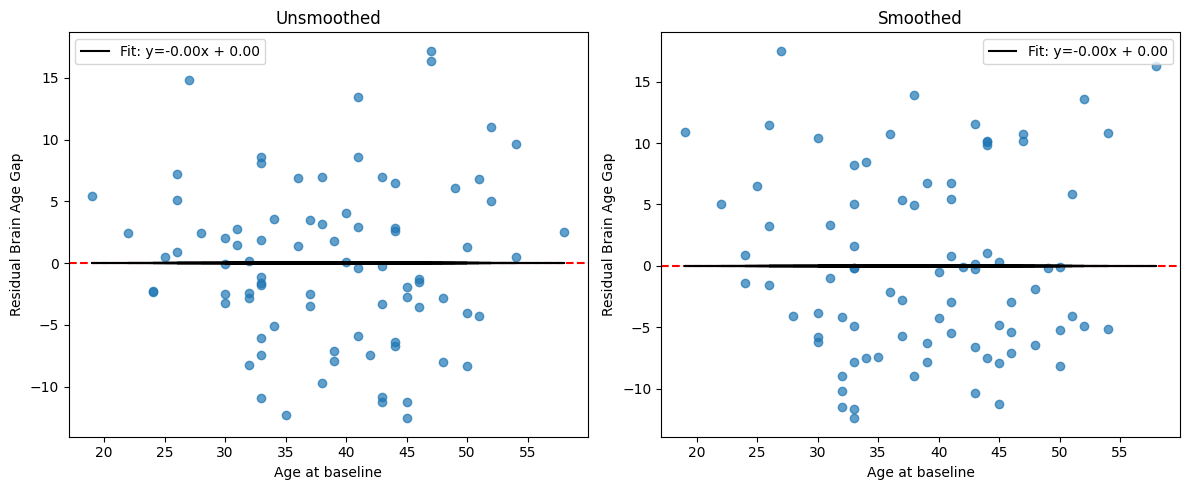

In [21]:
print("Residual BAG means:")
print("Unsmoothed:", df_unsmooth["BAG_residual"].mean())
print("Smoothed:", df_smooth["BAG_residual"].mean())

# Data
x_unsmooth = df_unsmooth["age_BL"]
y_residual_unsmooth = df_unsmooth["BAG_residual"]

x_smooth = df_smooth["age_BL"]
y_residual_smooth = df_smooth["BAG_residual"]

# Linear fits
m_residual_unsmooth, b_residual_unsmooth = np.polyfit(x_unsmooth, y_residual_unsmooth, 1)
m_residual_smooth, b_residual_smooth = np.polyfit(x_smooth, y_residual_smooth, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Unsmoothed residual
axes[0].scatter(x_unsmooth, y_residual_unsmooth, alpha=0.7)

axes[0].axhline(0, linestyle="--", color="red")

axes[0].plot(
    x_unsmooth,
    m_residual_unsmooth * x_unsmooth + b_residual_unsmooth,
    color="black",
    label=f"Fit: y={m_residual_unsmooth:.2f}x + {b_residual_unsmooth:.2f}"
)

axes[0].set_title("Unsmoothed")
axes[0].set_xlabel("Age at baseline")
axes[0].set_ylabel("Residual Brain Age Gap")
axes[0].legend()

# Smoothed residual
axes[1].scatter(x_smooth, y_residual_smooth, alpha=0.7)

axes[1].axhline(0, linestyle="--", color="red")

axes[1].plot(
    x_smooth,
    m_residual_smooth * x_smooth + b_residual_smooth,
    color="black",
    label=f"Fit: y={m_residual_smooth:.2f}x + {b_residual_smooth:.2f}"
)

axes[1].set_title("Smoothed")
axes[1].set_xlabel("Age at baseline")
axes[1].set_ylabel("Residual Brain Age Gap")
axes[1].legend()

plt.tight_layout()
# plt.savefig("MS_baseline_residual_BAG_unsmooth_vs_smooth.png", dpi=300, bbox_inches="tight")
plt.show()

Observation: Residualization removed the age dependency of BAG.

## BAG adjusted for age, sex, disease and  symptom duration

To account for potential confounding effects, a covariate-adjusted brain age gap (BAG_adj) are computed by regressing out age, sex, disease duration, and symptom duration. This makes it possible to isolate variation in BAG that is independent of these factors.

In [22]:
# Dataframe with predictions + disease/symptom duration
df_dato_subset = df_dato[['Patnr', 'DISEASE_DURATION', 'SYMPTOM_DURATION']].copy()
df_dato_subset = df_dato_subset.rename(columns={'DISEASE_DURATION': 'disease_duration','SYMPTOM_DURATION': 'symptom_duration'})
df_unsmooth = df_unsmooth.merge(df_dato_subset,left_on='participant_id',right_on='Patnr',how='left')
df_smooth = df_smooth.merge(df_dato_subset,left_on='participant_id',right_on='Patnr',how='left')

In [23]:
df_unsmooth.drop(columns=['Patnr'], inplace=True)
df_smooth.drop(columns=['Patnr'], inplace=True)

In [24]:
df_unsmooth.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,BAG_residual,disease_duration,symptom_duration
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,1.5,33.492504,-1.507496,33.919716,-1.080284,mild,-12.284878,0,2
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,2.5,40.867573,16.867573,41.207672,17.207672,mild,-2.254982,1,2
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,104,F,48.0,1.5,40.905470,-7.094528,41.245125,-6.754875,mild,-8.009435,0,18
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1101,F,46.0,2.0,44.873960,-1.126041,45.166737,-0.833263,mild,-3.558252,1,1
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1102,F,39.0,1.5,48.496895,9.496895,48.746880,9.746880,mild,1.754120,2,2


In [25]:
df_smooth.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,BAG_residual,disease_duration,symptom_duration
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,1.5,32.195694,-2.804306,32.905727,-2.094273,mild,-7.430194,0,2
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,2.5,36.474022,12.474022,37.120200,13.120201,mild,-1.413909,1,2
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,104,F,48.0,1.5,35.260303,-12.739697,35.924600,-12.075401,mild,-6.419534,0,18
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1101,F,46.0,2.0,36.009117,-9.990883,36.662235,-9.337765,mild,-5.354728,1,1
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1102,F,39.0,1.5,46.991196,7.991196,47.480396,8.480396,mild,6.733323,2,2


In [26]:
def correlation_with_bag(df, df_name):
    bag_cols = ["brain_age_gap", "brain_age_gap_bc"]
    variables = ["sex", "symptom_duration", "disease_duration"]

    print(f"\n===== {df_name} =====")

    for bag_col in bag_cols:
        print(f"\n--- Outcome: {bag_col} ---")

        for var in variables:
            tmp = df[[bag_col, var]].dropna().copy()
            n = len(tmp)

            if n < 3:
                print(f"{var}: Not enough data, n = {n}")
                continue

            if var == "sex":
                # Map F/M -> 0/1
                tmp[var] = tmp[var].map({"F": 0, "M": 1})


                tmp = tmp.dropna()
                n = len(tmp)

                if n < 3:
                    print(f"{var}: Not enough data after mapping, n = {n}")
                    continue

                r, p = stats.pearsonr(tmp[var], tmp[bag_col])

            else:
                r, p = stats.pearsonr(tmp[var], tmp[bag_col])

            ci_lo, ci_hi = pearson_ci(r, n)

            print(
                f"Pearson({bag_col}, {var}) = "
                f"r = {r:.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}], "
                f"p = {p:.3e}, n = {n}"
            )


correlation_with_bag(df_unsmooth, "Unsmoothed")
correlation_with_bag(df_smooth, "Smoothed")


===== Unsmoothed =====

--- Outcome: brain_age_gap ---
Pearson(brain_age_gap, sex) = r = -0.085, 95% CI [-0.301, 0.141], p = 4.618e-01, n = 78
Pearson(brain_age_gap, symptom_duration) = r = -0.206, 95% CI [-0.404, 0.010], p = 6.110e-02, n = 83
Pearson(brain_age_gap, disease_duration) = r = -0.066, 95% CI [-0.278, 0.152], p = 5.521e-01, n = 83

--- Outcome: brain_age_gap_bc ---
Pearson(brain_age_gap_bc, sex) = r = -0.086, 95% CI [-0.302, 0.140], p = 4.566e-01, n = 78
Pearson(brain_age_gap_bc, symptom_duration) = r = -0.208, 95% CI [-0.406, 0.008], p = 5.887e-02, n = 83
Pearson(brain_age_gap_bc, disease_duration) = r = -0.066, 95% CI [-0.278, 0.152], p = 5.527e-01, n = 83

===== Smoothed =====

--- Outcome: brain_age_gap ---
Pearson(brain_age_gap, sex) = r = -0.117, 95% CI [-0.331, 0.109], p = 3.091e-01, n = 78
Pearson(brain_age_gap, symptom_duration) = r = -0.213, 95% CI [-0.410, 0.002], p = 5.269e-02, n = 83
Pearson(brain_age_gap, disease_duration) = r = -0.049, 95% CI [-0.262, 0.169]

### Modifying BAG (age, sex, disease and symptom duration)

In [27]:
model_unsmooth = smf.ols('brain_age_gap ~ age_BL + C(sex) + disease_duration + symptom_duration',data=df_unsmooth).fit()
df_unsmooth['BAG_adj'] = model_unsmooth.resid

In [28]:
model_smooth = smf.ols('brain_age_gap ~ age_BL + C(sex) + disease_duration + symptom_duration',data=df_smooth).fit()
df_smooth['BAG_adj'] = model_smooth.resid

In [29]:
df_unsmooth.head()

,image_path,participant_id,sex,age_BL,EDSS_BL,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc,edss_group,BAG_residual,disease_duration,symptom_duration,BAG_adj
0,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,101,F,35.0,1.5,33.492504,-1.507496,33.919716,-1.080284,mild,-12.284878,0,2,-12.475490
1,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,103,M,24.0,2.5,40.867573,16.867573,41.207672,17.207672,mild,-2.254982,1,2,-3.350060
2,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,104,F,48.0,1.5,40.905470,-7.094528,41.245125,-6.754875,mild,-8.009435,0,18,-7.335937
3,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1101,F,46.0,2.0,44.873960,-1.126041,45.166737,-0.833263,mild,-3.558252,1,1,-3.201111
4,/hus/home/aaasen/Master_thesis/VBM_project_MS/...,1102,F,39.0,1.5,48.496895,9.496895,48.746880,9.746880,mild,1.754120,2,2,1.946152


## Correlation: Adjusted BAG and age/sex/syptom/disease duration

In [30]:
def run_pearson_tests(df, bag_column, label):
    
    print(f"\n===== {label} =====")
    
    variables = ['age_BL', 'disease_duration', 'symptom_duration']
    
    for var in variables:
        tmp = df[[bag_column, var]].replace([np.inf, -np.inf], np.nan).dropna()
        
        r, p = pearsonr(tmp[bag_column], tmp[var])
        n = len(tmp)
        ci_lo, ci_hi = pearson_ci(r, n)
        
        print(
            f"{bag_column} vs {var}: "
            f"r = {r:.3f}, "
            f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}], "
            f"p = {p:.4g}, "
            f"n = {n}"
        )

In [31]:
print("Pearson correlation:")
# UNSMOOTHED
run_pearson_tests(df_unsmooth, 'BAG_adj', 'Unsmoothed')

# SMOOTHED
run_pearson_tests(df_smooth, 'BAG_adj', 'Smoothed')

Pearson correlation:

===== Unsmoothed =====
BAG_adj vs age_BL: r = 0.000, 95% CI [-0.223, 0.223], p = 1, n = 78
BAG_adj vs disease_duration: r = 0.000, 95% CI [-0.223, 0.223], p = 1, n = 78
BAG_adj vs symptom_duration: r = 0.000, 95% CI [-0.223, 0.223], p = 1, n = 78

===== Smoothed =====
BAG_adj vs age_BL: r = -0.000, 95% CI [-0.223, 0.223], p = 1, n = 78
BAG_adj vs disease_duration: r = 0.000, 95% CI [-0.223, 0.223], p = 1, n = 78
BAG_adj vs symptom_duration: r = 0.000, 95% CI [-0.223, 0.223], p = 1, n = 78


In [32]:
# T test and Mann-Whitney U
from scipy.stats import ttest_ind, mannwhitneyu
import numpy as np

def run_sex_tests(df, bag_column, label):
    
    print(f"\n===== {label} =====")
    
    # Fjern NaN
    tmp = df[[bag_column, 'sex']].replace([np.inf, -np.inf], np.nan).dropna()
    
    # Del opp i grupper
    group_M = tmp[tmp['sex'] == 'M'][bag_column]
    group_F = tmp[tmp['sex'] == 'F'][bag_column]
    
    print(f"\nTesting {bag_column} between sexes (M vs F)")
    print(f"N (M) = {len(group_M)}, N (F) = {len(group_F)}")
    
    # T-test
    t_stat, t_p = ttest_ind(group_M, group_F, nan_policy='omit')
    print(f"T-test: t = {t_stat:.3f}, p = {t_p:.4g}")
    
    # Mann-Whitney
    u_stat, u_p = mannwhitneyu(group_M, group_F)
    print(f"Mann–Whitney U: U = {u_stat:.1f}, p = {u_p:.4g}")

In [33]:
# UNSMOOTHED
run_sex_tests(df_unsmooth, 'BAG_adj', 'Unsmoothed - Adjusted BAG')

# SMOOTHED
run_sex_tests(df_smooth, 'BAG_adj', 'Smoothed - Adjusted BAG')


===== Unsmoothed - Adjusted BAG =====

Testing BAG_adj between sexes (M vs F)
N (M) = 28, N (F) = 50
T-test: t = -0.000, p = 1
Mann–Whitney U: U = 690.0, p = 0.9212

===== Smoothed - Adjusted BAG =====

Testing BAG_adj between sexes (M vs F)
N (M) = 28, N (F) = 50
T-test: t = -0.000, p = 1
Mann–Whitney U: U = 712.0, p = 0.9047


Observation: No association between adjusted BAG (raw and bias-corrected) and age/sex/symptom/disease duration for either model variant.

## Plot: Adjusted BAG vs cronological age

Adjusted BAG means:
Unsmoothed: -4.628775994975653e-15
Smoothed: -6.376665577334232e-16


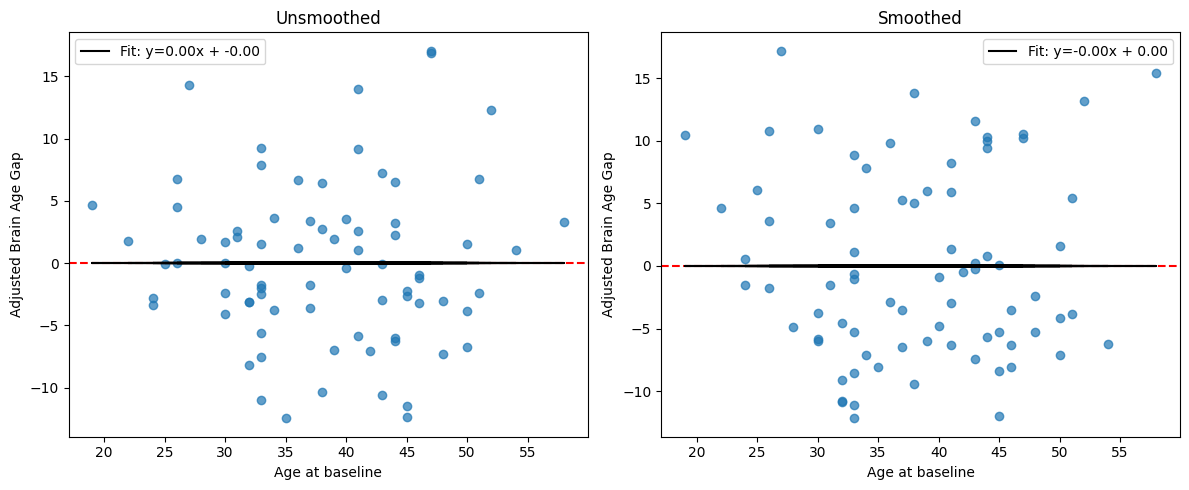

In [34]:
print("Adjusted BAG means:")
print("Unsmoothed:", df_unsmooth["BAG_adj"].mean())
print("Smoothed:", df_smooth["BAG_adj"].mean())

tmp_unsmooth = df_unsmooth[["age_BL", "BAG_adj"]].replace([np.inf, -np.inf], np.nan).dropna()
tmp_smooth = df_smooth[["age_BL", "BAG_adj"]].replace([np.inf, -np.inf], np.nan).dropna()

x_unsmooth = tmp_unsmooth["age_BL"]
y_adj_unsmooth = tmp_unsmooth["BAG_adj"]

x_smooth = tmp_smooth["age_BL"]
y_adj_smooth = tmp_smooth["BAG_adj"]

m_adj_unsmooth, b_adj_unsmooth = np.polyfit(x_unsmooth, y_adj_unsmooth, 1)
m_adj_smooth, b_adj_smooth = np.polyfit(x_smooth, y_adj_smooth, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Unsmoothed
axes[0].scatter(x_unsmooth, y_adj_unsmooth, alpha=0.7)
axes[0].axhline(0, linestyle="--", color="red")
axes[0].plot(
    x_unsmooth,
    m_adj_unsmooth * x_unsmooth + b_adj_unsmooth,
    color="black",
    label=f"Fit: y={m_adj_unsmooth:.2f}x + {b_adj_unsmooth:.2f}"
)
axes[0].set_title("Unsmoothed")
axes[0].set_xlabel("Age at baseline")
axes[0].set_ylabel("Adjusted Brain Age Gap")
axes[0].legend()

# Smoothed
axes[1].scatter(x_smooth, y_adj_smooth, alpha=0.7)
axes[1].axhline(0, linestyle="--", color="red")
axes[1].plot(
    x_smooth,
    m_adj_smooth * x_smooth + b_adj_smooth,
    color="black",
    label=f"Fit: y={m_adj_smooth:.2f}x + {b_adj_smooth:.2f}"
)
axes[1].set_title("Smoothed")
axes[1].set_xlabel("Age at baseline")
axes[1].set_ylabel("Adjusted Brain Age Gap")
axes[1].legend()

plt.tight_layout()
# plt.savefig("MS_baseline_adjusted_BAG_unsmooth_vs_smooth.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
#df_unsmooth.to_csv("df_unsmooth_with_adjusted_BAG.csv", index=False)
#df_smooth.to_csv("df_smooth_with_adjusted_BAG.csv", index=False)